# Fase 2: Ingeniería de Características y Exploración Visual
**Objetivo:** Sintetizar biomarcadores avanzados a partir de medidas físicas crudas y visualizar su impacto directo en el riesgo de hipertensión.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Carga de datos de la sala de procesamiento
input_path = "../data/processed/Hipertension_Limpio.csv"
df = pd.read_csv(input_path)

print("Datos limpios cargados")

Datos limpios cargados


### Creación de Nuevas Variables Clínicas
1. **Índice Cintura-Talla (ICT):** Dividir la cintura entre la estatura. Es un predictor cardiovascular superior al IMC, ya que evalúa la grasa visceral (abdominal). Un valor > 0.5 indica riesgo.
2. **Índice TyG (Triglicéridos y Glucosa):** Un biomarcador validado científicamente para detectar resistencia a la insulina.

In [6]:
# 1. Recalcular el IMC (El original tenía errores graves)
# Formula: Peso (kg) / Estatura (m)^2. Nota: La estuatura en el dataset está en cm.
df['imc_calculado'] = df['peso'] / ((df['estatura'] / 100) ** 2)

# 2. índice Cintura/Estatura (ICT)
df['indice_cintura_talla'] = df['medida_cintura'] / df['estatura']

# 3. Índice TyG (Fórmula logarítmica: ln[triglicéridos(mg/dL) * glucosa(mg/dL) / 2])
# Uso de np.log para el logaritmo natural
df['indice_tyg'] = np.log((df['valor_trigliceridos'] * df['resultado_glucosa']) / 2)
print("Nuevos biomarcadores sintetizados con éxito:")
df[['peso', 'estatura', 'medida_cintura', 'imc_calculado', 'indice_cintura_talla', 'indice_tyg']].head(3)

Nuevos biomarcadores sintetizados con éxito:


,peso,estatura,medida_cintura,imc_calculado,indice_cintura_talla,indice_tyg
0,74.55,147.3,103.66,34.359130,0.703734,8.640826
1,96.75,151.0,113.70,42.432349,0.752980,8.891580
2,68.70,151.0,103.70,30.130257,0.686755,8.640826


### Análisis Visual: ¿Qué dispara realmente la Hipertensión?
Se crearán gráficos de caja (Boxplots) para comparar cómo se comportan nuestros nuevos biomarcadores en pacientes sanos (0) vs pacientes en riesgo (1).

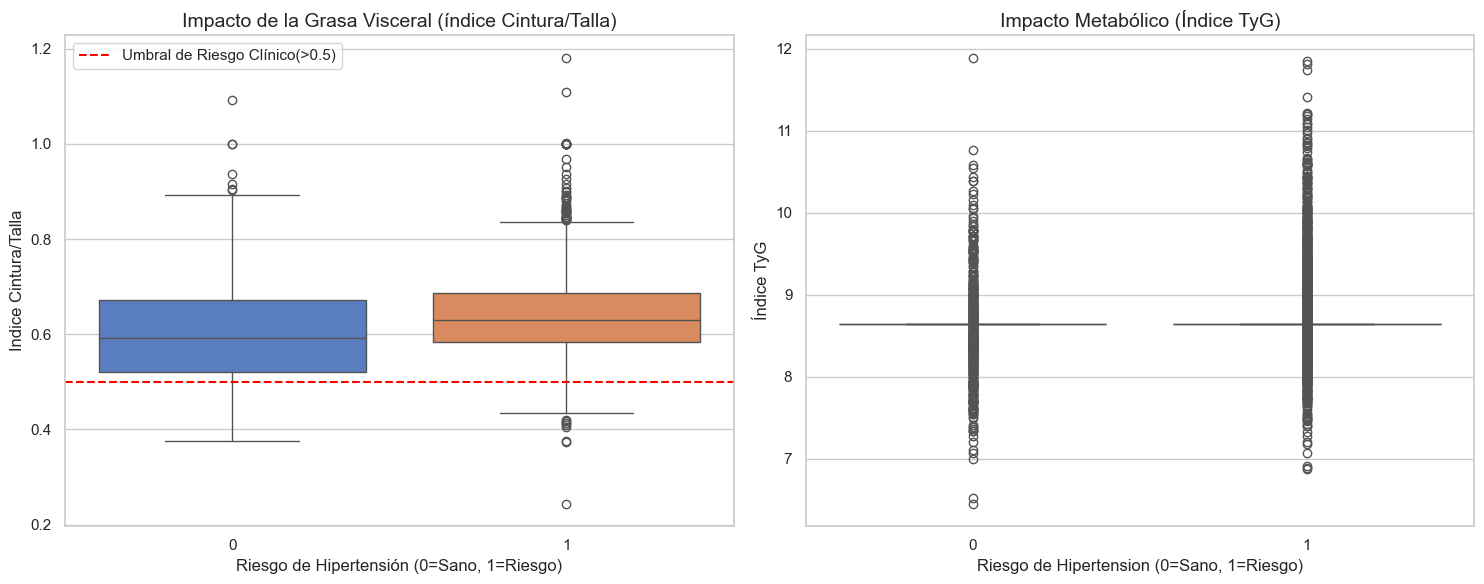

Matriz con biomarcadores guardada en: ../data/processed/Hipertension_Features.csv


In [10]:
# Creación de lienzo (figura) con dos gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1. índice Cintura/talla vs Hipertensión
sns.boxplot(
    data=df,
    x="riesgo_hipertension",
    y="indice_cintura_talla",
    ax=axes[0],
    hue='riesgo_hipertension',
    legend=False
) 
axes[0].set_title('Impacto de la Grasa Visceral (índice Cintura/Talla)', fontsize=14)
axes[0].set_xlabel('Riesgo de Hipertensión (0=Sano, 1=Riesgo)', fontsize=12)
axes[0].set_ylabel('Indice Cintura/Talla', fontsize=12)
axes[0].axhline(0.5, color='red', linestyle='--', label='Umbral de Riesgo Clínico(>0.5)')
axes[0].legend()

# Gráfica 2: Índice TyG (Resistencia a la Insulina) vs Hipertensión
sns.boxplot(
    data=df,
    x='riesgo_hipertension',
    y='indice_tyg',
    ax=axes[1],
    hue='riesgo_hipertension',
    legend=False
)
axes[1].set_title('Impacto Metabólico (Índice TyG)', fontsize=14)
axes[1].set_xlabel('Riesgo de Hipertension (0=Sano, 1=Riesgo)', fontsize=12)
axes[1].set_ylabel('Índice TyG', fontsize=12)

plt.tight_layout()
plt.show()


# Guardar la matriz enriquecida con los nuevos biomarcadores
output_features_path = "../data/processed/Hipertension_Features.csv"
df.to_csv(output_features_path, index=False)
print(f"Matriz con biomarcadores guardada en: {output_features_path}")